# LLM Trees - Decision Trees through LLMs

#### Members:
- Jasmine Jassi
- Sam Olamazadeh
- Tharindu(Tharu) Yakkala A. Don, 501220016
####  Emails:
- tyakkala@torontomu.ca
- jasmine.jassi@torontomu.ca

# Introduction:

#### Problem Description:

This project aims to implement zero-shot prompting to generate decision-trees using a pre-trained LLM, namely Gemini 2.5 Flash, to observe how the model utilizes its world knowledge from pre-training for predictive modeling with 5 different datasets. This study follows the paper '"OH LLM, I'm Asking Thee, Please Give Me a Decision Tree": Zero-Shot Decision Tree Induction and Embedding with Large Language Models' by Knauer et. al.

#### Context of the Problem:

Training large language models, depending on the task and dataset at hand, can prove to be both computationally and literally expensive. In addition, with proprietary datasets, it can be a privacy issue to input sensitive details into public models, limiting the amount of data that can be used in training these models. Such a situation where data is scarce can be referred to as a "low-data regime" [1]. However, the general knowledge that these pre-trained models have can still be applicable or useful for generating models that can then be used for proprietary or smaller datasets, removing the issue for privacy as no training data is passed to the model; only feature names. The aspect of "knowledge distillation" to generate decision trees goes hand-in-hand with applying in-context learning, creating an approach to generate "intrinsically interpretable machine learning models" [1]. While the paper extends to embeddings analysis, this project focuses on the induction component (generating and evaluating the decision trees through zero-shot prompting).

#### Limitation About other Approaches:

Previous studies involved generating features without training data [1] and a few labeled examples [2] using LLMs. However, this project (and paper) focuses on building actual models that can be used to further interpret data without any training required.

#### Solution:

Rather than giving state-of-art LLMs access to proprietary data as examples, only important feature names are provided and the LLM is zero-shot prompted to create the best possible decision tree based on the knowledge it has. Similar to the paper, we use the decision trees to classify 5 different datasets and analyze the classification reports for accuray, precision and F1 values.

# Background

| Reference |Explanation |  Dataset/Input |Weakness
| --- | --- | --- | --- |
| Nam et al. [2] | They proposed OCTree, a framework that uses LLMs to iteratively generate new column <br> features for tabular prediction tasks. <br> The LLM is prompted to return a feature name and generation rule <br> (using no training data in LLM prompt itself). <br> New feature used to augment data and combined data used to train decision tree. | Multiple tabular classification/regression benchmarks <br> (including Kaggle datasets); <br> CART algorithm and Llama 2 7B (fine-tuned) model | Evaluating generated features can be time-consuming if model requires <br> extensive training but the authors note this issue can be mitigated by <br> generating features with simpler prediction model first and then <br> using them in the target model
| Han et al. [3] | They use FeatLLM (in-context learning framework) that uses LLMs to as feature engineers <br> to create optimal input dataset for tabular tasks. LLM is prompted with few labeled <br> examples and extracts rules associated with each class. The rules are used to create <br> binary features as inputs for a linear model to estimate likelihood of each class. | 13 different tabular datasets in low-shot regimes; <br> FeatLLM uses GPT-3.5 | Only generated binary features (limited representations); <br> Automated parsing via LLM error rates higher for data with many <br> categorical features; <br> Biases and misinformation embedded in the prior knowledge of LLMs should <br> be considered
| Knauer et al. [1] | They use zero-shot prompting to generate decision trees without any training data. <br> They also create embeddings from these decision trees for <br> downstream models. | Small-sized tabular datasets from public Penn Machine <br> Learning Benchmarks (PMLB); <br> 4 state-of-the-art LLMs and 5 ML baselines | Focused on small-sized tabular datasets (question whether results <br> extend in other settings); <br> Used a simple prompting template (whether it captures all the complexity); <br> Can use more powerful LLMs (biases and prior knowledge of LLMs should be considered) <br> 


# Methodology

We used the same datasets used by Knauer et al. where they only utilized various datasets that were less than or equal to 500 rows. All datasets are classification based and have a binary target. The authors chose these datasets because the feature names were not ambiguous, and could easily be understood by an LLM along with some descriptions of them. Originally the paper used 15 public datasets, however we reduced that down to 5; acl, bankruptcy, boxing1, boxing2, and colic.

We created a prompt using the same initial prompt used by Knauer et al, but a more simplified single prompt method. The prompting strategy used by them typically consists of multiple prompts where LLMs are prompted in sequential steps. First the decision tree sturcture is extracted, and then the LLM is asked to create a function which the features can be provided to, that outputs a classification and also a set of features that represents the decision logic within the treee (Knauer et al., 2025). The unified system prompt contains the following, a personal section that tells the LLM it is a domain expert capable of generating Decision trees without any direct training data, and instead use it's vast internal training data, and two sequence of steps for outputting the decision internally and then using that to generate the function. For the user prompt, the LLM is given a short description of the dataset's domain and background, along with the desciption of the feature names, data types and expected input/output format of each feature/label (Knauer et al., 2025).

<p align="center">
    <img src="src/figures/llm_flow.png" alt="LLM dt extraction flow" width="500"/>
</p>

Initially we used a platform called Open Router that provided some state of the art open source models through free apis, however after initial testing we found that endpoint to be quite slow. We found that there is a free api on colab that allows you to use Gemini 2.5 Flash without an api key, the system and user prompt were then combined into one main prompt, where it was fed into Google Colab's free AI API. From these prompts the model is prompted five times per dataset, to extract five various decision tree classifiers. These outputs from the model are then used as the backbone of the classifers for which we test the metrics, such as, f1-score, accuracy, recall, and precision of each decision tree function generated by Gemini. As there could be various in the use of the parameters in each funciton, we will then edit some parts of these functions to be more uniform, however, the decision logic outputted by the LLM will remain. We also assess the ensemble capabilities by utilizing a voting style ensemble, where the final label is the most classified label. Since we do not have a train/test split, as the decision tree logic is extracted directly from the LLM, we will use all the rows of each dataset as the test set. As a result we have 25 decision tree functions in total, where for each dataset there is 5. Below is a simplified version of how each function works and an example output.
<p align="center">
    <img src="src/figures/func_example_full.png" alt="Function example" width="300"/>
</p>

# Implementation

### LLM Tree Extraciton

The extraction is done through colab's google.colab.ai api, which provides a free api.

**Sample outputs**

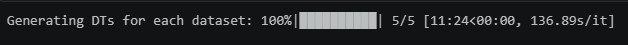

The following are the output function logic from the LLM

![Alternate text ](src/figures/sample_output.png "Title of the figure, location is simply the directory of the notebook")

![Alternate text ](src/figures/sample_output2.png "Title of the figure, location is simply the directory of the notebook")

### Tree Evaluation

In [ ]:
# Code cells
from src.Evaluators import (
    evaluate_bankruptcy,
    evaluate_boxing1,
    evaluate_boxing2,
    evaluate_colic,
    evaluate_creditscore
)


evaluate_bankruptcy.evaluate()

BANKRUPTCY DATASET - Zero-Shot Decision Tree Evaluation
Dataset size: 50 | Bankrupt(1)=25, Non-Bankrupt(0)=25

  Model_0: Accuracy=0.5600  Precision=0.5484  Recall=0.6800  F1=0.6071
  Model_1: Accuracy=0.6400  Precision=0.6522  Recall=0.6000  F1=0.6250
  Model_2: Accuracy=0.5800  Precision=0.6000  Recall=0.4800  F1=0.5333
  Model_3: Accuracy=0.8600  Precision=0.8214  Recall=0.9200  F1=0.8679
  Model_4: Accuracy=0.7800  Precision=0.7059  Recall=0.9600  F1=0.8136

  Ensemble (Majority Voting): Accuracy=0.6800  Precision=0.6800  Recall=0.6800  F1=0.6800

              precision    recall  f1-score   support

Non-Bankrupt       0.68      0.68      0.68        25
    Bankrupt       0.68      0.68      0.68        25

    accuracy                           0.68        50
   macro avg       0.68      0.68      0.68        50
weighted avg       0.68      0.68      0.68        50



In [6]:
# Code cells
evaluate_boxing1.evaluate()

BOXING1 (Lewis vs Holyfield) - Zero-Shot Decision Tree Evaluation
Dataset size: 120 | Lewis(1)=78, Holyfield(0)=42

  Model_0: Accuracy=0.6500  Precision=0.6500  Recall=1.0000  F1=0.7879
  Model_1: Accuracy=0.6667  Precision=0.7262  Recall=0.7821  F1=0.7531
  Model_2: Accuracy=0.7167  Precision=0.7157  Recall=0.9359  F1=0.8111
  Model_3: Accuracy=0.6500  Precision=0.6500  Recall=1.0000  F1=0.7879
  Model_4: Accuracy=0.6000  Precision=0.6471  Recall=0.8462  F1=0.7333

  Ensemble (Majority Voting): Accuracy=0.6500  Precision=0.6500  Recall=1.0000  F1=0.7879

              precision    recall  f1-score   support

   Holyfield       0.00      0.00      0.00        42
       Lewis       0.65      1.00      0.79        78

    accuracy                           0.65       120
   macro avg       0.33      0.50      0.39       120
weighted avg       0.42      0.65      0.51       120



In [7]:
# Code cells
evaluate_boxing2.evaluate()

BOXING2 (Trinidad vs de la Hoya) - Zero-Shot Decision Tree Evaluation
Dataset size: 132 | de la Hoya(1)=71, Trinidad(0)=61

  Model_0: Accuracy=0.4773  Precision=0.5333  Recall=0.2254  F1=0.3168
  Model_1: Accuracy=0.4773  Precision=0.5333  Recall=0.2254  F1=0.3168
  Model_2: Accuracy=0.6288  Precision=0.6667  Recall=0.6197  F1=0.6423
  Model_3: Accuracy=0.5833  Precision=0.5702  Recall=0.9155  F1=0.7027
  Model_4: Accuracy=0.5985  Precision=0.6250  Recall=0.6338  F1=0.6294

  Ensemble (Majority Voting): Accuracy=0.6136  Precision=0.6389  Recall=0.6479  F1=0.6434

              precision    recall  f1-score   support

    Trinidad       0.58      0.57      0.58        61
  de la Hoya       0.64      0.65      0.64        71

    accuracy                           0.61       132
   macro avg       0.61      0.61      0.61       132
weighted avg       0.61      0.61      0.61       132



In [8]:
evaluate_colic.evaluate()

COLIC (Horse) DATASET - Zero-Shot Decision Tree Evaluation
Dataset size: 368 | Surgical(1)=232, Non-Surgical(0)=136

  Model_0: Accuracy=0.7201  Precision=0.8377  Recall=0.6897  F1=0.7565
  Model_1: Accuracy=0.5924  Precision=0.7733  Recall=0.5000  F1=0.6073
  Model_2: Accuracy=0.7201  Precision=0.8377  Recall=0.6897  F1=0.7565
  Model_3: Accuracy=0.7201  Precision=0.8377  Recall=0.6897  F1=0.7565
  Model_4: Accuracy=0.6005  Precision=0.8295  Recall=0.4612  F1=0.5928

  Ensemble (Majority Voting): Accuracy=0.7201  Precision=0.8377  Recall=0.6897  F1=0.7565

              precision    recall  f1-score   support

Non-Surgical       0.59      0.77      0.67       136
    Surgical       0.84      0.69      0.76       232

    accuracy                           0.72       368
   macro avg       0.72      0.73      0.71       368
weighted avg       0.75      0.72      0.72       368



In [4]:
evaluate_creditscore.evaluate()

CREDIT SCORE DATASET - Zero-Shot Decision Tree Evaluation
Dataset size: 100 | Accepted(1)=73, Rejected(0)=27

  Model_0: Accuracy=0.4000  Precision=0.8824  Recall=0.2055  F1=0.3333
  Model_1: Accuracy=0.4000  Precision=0.8421  Recall=0.2192  F1=0.3478
  Model_2: Accuracy=0.5000  Precision=0.7949  Recall=0.4247  F1=0.5536
  Model_3: Accuracy=0.3600  Precision=0.9091  Recall=0.1370  F1=0.2381
  Model_4: Accuracy=0.4000  Precision=0.8421  Recall=0.2192  F1=0.3478

  Ensemble (Majority Voting): Accuracy=0.4000  Precision=0.8421  Recall=0.2192  F1=0.3478

              precision    recall  f1-score   support

    Rejected       0.30      0.89      0.44        27
    Accepted       0.84      0.22      0.35        73

    accuracy                           0.40       100
   macro avg       0.57      0.55      0.40       100
weighted avg       0.69      0.40      0.37       100



# Conclusion and Future Direction

Generally, we find that the ensemble of the 5 models doesn’t always result in a better accuracy compared to individual models themselves. This is due to the fact that of the 5 models generated by the LLM there is typically going to be some that do a lot more poorly than others and vice versa. Typically, when there is less variance among the model metrics, the ensemble results are more stable. For instance, on the colic dataset, the accuracy(72%) and f1 score (71%) is around the range of the metrics of the individual models for that dataset. However, for the bankruptcy dataset, there is a model that outperforms all of them with an accuracy of 86% and f1 score of 81% compared to the ensemble accuracy of 68% and f1 of 68%. This is due the fact that most of the other models performed much worse. If we set a baseline of the model guessing every time it would have 50% accuracy, then all except the creditscore dataset perform much higher than this random baseline. This could indicate that LLMs do have the inherent ability to distill its knowledge of the vast amount of information that it was trained upon, to apply its own internal reasoning to generate the decision tree logic, along with sample functions.

The limitations of these results also stem from the fact that we couldn’t really compare it to a decision tree from sci kit learn, because those models just always get 100% accuracy on small datasets. Even if we were to split the datasets, into train and test, the datasets themselves are quite small ranging from 50-368. This was also mentioned by Knauer et al., because the results of the models are based on small datasets, so there is still work to be done to compare it to larger datasets. Other future steps would be to utilize the features that the models can also output based on the decision nodes, we think that these could be beneficial in order to perhaps to see if they increase model accuracy. We also only compared the results from one LLM, so utilizing more frontier models such as GPT, Claude, ande even open source models such as, Qwen could be done to compare different models and their ability to distill their information.



# References:

[1]:  Knauer, R., Koddenbrock, M., Wallsberger, R., Brisson, N. M., Duda, G. N., Falla, D., Evans, D. W., & Rodner, E. (2025). “Oh LLM, I’m Asking Thee, Please Give Me a Decision Tree”: Zero-Shot Decision Tree Induction and Embedding with Large Language Models. Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining V.2, 1196–1206. https://doi.org/10.1145/3711896.3736818


[2]:  Jaehyun Nam, Kyuyoung Kim, Seunghyuk Oh, Jihoon Tack, Jaehyung Kim, andJinwoo Shin. 2024. Optimized Feature Generation for Tabular Data via LLMswith Decision Tree Reasoning. Advances in neural information processing systems37 (2024). doi:10.48550/arXiv.2406.08527. https://doi.org/10.48550/arXiv.2406.08527

[3]:  Sungwon Han, Jinsung Yoon, Sercan Ö Arik, and Tomas Pfister. 2024. Large Language Models Can Automatically Engineer Features for Few-Shot Tabular Learning. In Proceedings of the 41st International Conference on Machine Learning (ICML).PMLR, Vienna, Austria, 17454–17479. https://doi.org/10.48550/arXiv.2404.09491
